# Laboratorio 9 - Redes Neuronales

## Readaptación del set de variables predictoras

Durante el desarrollo de los modelos de redes neuronales (incisos 1–10) se identificó que el conjunto inicial de **5 variables numéricas** heredado del Laboratorio 8 (`accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`) presentaba una correlación lineal muy baja con el precio (máximo de **0.10**). Como consecuencia, los modelos de RNA alcanzaban un techo artificial de aproximadamente **0.63 de accuracy** en clasificación y **R² ≈ 0.38** en regresión, independientemente de la arquitectura utilizada.

Un análisis adicional del dataset evidenció que dos variables omitidas son determinantes para predecir el precio:

- **`room_type`**: distribuye drásticamente las categorías de precio (Shared room → 95% Económico, Hotel room → 75% Caro, Entire home → mayoritariamente Intermedio).
- **`neighbourhood_group_cleansed`**: el precio promedio varía hasta **8 veces** entre regiones (Kent: ~$188 vs Newport: ~$1,589).

Sin estas variables los modelos resultaban *ciegos* al tipo de alojamiento y a la ubicación geográfica, los dos predictores más fuertes en cualquier dataset de Airbnb.

### Decisión

A partir de esta entrega, **todos los modelos del Laboratorio 9** (incisos 1–17) se entrenan con un set ampliado de **15 variables**:

**Numéricas (13):** `accommodates`, `bathrooms`, `bedrooms`, `beds`, `review_scores_rating`, `minimum_nights`, `availability_365`, `number_of_reviews`, `reviews_per_month`, `latitude`, `longitude`, `review_scores_location`, `review_scores_cleanliness`.

**Categóricas (2, codificadas con OneHotEncoder):** `room_type`, `neighbourhood_group_cleansed`.

Para que la comparación con los algoritmos de los Laboratorios 7 y 8 (incisos 14–16) sea válida bajo el principio de "mismas condiciones", esos modelos se **vuelven a entrenar dentro de este mismo notebook** con el set ampliado, no se reutilizan las métricas reportadas en sus entregas originales.

El pipeline de preprocesamiento se centraliza en un `ColumnTransformer` que aplica imputación y escalado a las numéricas, y `OneHotEncoder` a las categóricas. El mismo pipeline se reutiliza para clasificación y regresión, y el split (70/30, `random_state=42`, `stratify=y_categorica`) garantiza que ambos problemas comparten exactamente las mismas filas de entrenamiento y prueba.

In [43]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
import pyreadr
import time
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.impute import SimpleImputer

from sklearn.compose import make_column_selector as selector  # selección automática de numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder              # codificación one-hot para categóricas
from sklearn.preprocessing import StandardScaler             # normalización de numéricas
from sklearn.compose import ColumnTransformer                # combina preprocesadores por columna
from sklearn.pipeline import make_pipeline, Pipeline         # secuencias de pasos
from sklearn import set_config
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')

# Métricas
from sklearn.metrics import make_scorer, accuracy_score, precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [44]:
result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### 1. Conjuntos Train y Test

In [45]:
#Limpieza de datos

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["price"])

In [46]:
def categorize_price(price):
    if price <= 120:
        return "Economico"
    elif price <= 326:
        return "Intermedio"
    else:
        return "Caro"

df["price_category"] = df["price"].apply(categorize_price)

In [47]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [48]:
# variables predictoras
X = df.drop(columns=["price", "price_category"])

# variable objetivo (clasificación)
y = df["price_category"]

In [49]:

pd.Series(y).value_counts(normalize=True)

price_category
Intermedio    0.496839
Economico     0.253259
Caro          0.249902
Name: proportion, dtype: float64

In [50]:
# ============================================================
# Set ampliado de variables predictoras (ver sección "Readaptación" al inicio)
# ============================================================
NUM_FEATURES = [
    "accommodates", "bathrooms", "bedrooms", "beds",
    "review_scores_rating", "minimum_nights", "availability_365",
    "number_of_reviews", "reviews_per_month",
    "latitude", "longitude",
    "review_scores_location", "review_scores_cleanliness",
]
CAT_FEATURES = ["room_type", "neighbourhood_group_cleansed"]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df[ALL_FEATURES]
y = df["price_category"]

# Pipeline de preprocesamiento centralizado:
#   - numéricas: imputación con la media + estandarización
#   - categóricas: OneHotEncoder (handle_unknown='ignore' por seguridad)
preprocesador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="mean")),
            ("sc",  StandardScaler()),
        ]), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ]
)

# Split 70/30 estratificado por la categoría de precio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicación del preprocesador (fit en train, transform en test)
X_train_scaled = preprocesador.fit_transform(X_train)
X_test_scaled  = preprocesador.transform(X_test)

print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled :", X_test_scaled.shape)

Shape X_train_scaled: (53372, 27)
Shape X_test_scaled : (22874, 27)


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 2. Exploración y Transformación

In [51]:
# El escalado y la codificación de las categóricas ya se aplicaron dentro del
# ColumnTransformer de la celda anterior. X_train_scaled y X_test_scaled
# contienen los datos numéricos estandarizados + las dummies one-hot.
print(f"Variables tras preprocesamiento: {X_train_scaled.shape[1]} columnas")
print(f"  - Numéricas estandarizadas: {len(NUM_FEATURES)}")
print(f"  - Dummies one-hot         : {X_train_scaled.shape[1] - len(NUM_FEATURES)}")

Variables tras preprocesamiento: 27 columnas
  - Numéricas estandarizadas: 13
  - Dummies one-hot         : 14


Para este ejercicio, las variables respuestas son y_train y y_test que representan el precio. Estas representan:

- Económico
- Intermedio
- Caro

### 3. Crear DOS modelos de RNA (clasificación)

In [52]:
#SIMPLE

mlp1 = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    max_iter=200,
    random_state=42
)

mlp1.fit(X_train_scaled, y_train)

y_pred_mlp1 = mlp1.predict(X_test_scaled)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [53]:
# COMPLEJO

mlp2 = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='tanh',
    max_iter=200,
    random_state=42
)

mlp2.fit(X_train_scaled, y_train)

y_pred_mlp2 = mlp2.predict(X_test_scaled)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 4. Valores modelos

In [54]:
print("Modelo 1 entrenado con: ", y_pred_mlp1)
print("\nModelo 2 entrenado con: ", y_pred_mlp2)

Modelo 1 entrenado con:  ['Intermedio' 'Economico' 'Caro' ... 'Intermedio' 'Economico' 'Intermedio']

Modelo 2 entrenado con:  ['Intermedio' 'Economico' 'Caro' ... 'Intermedio' 'Economico' 'Caro']


### 5. Matrices de confusión

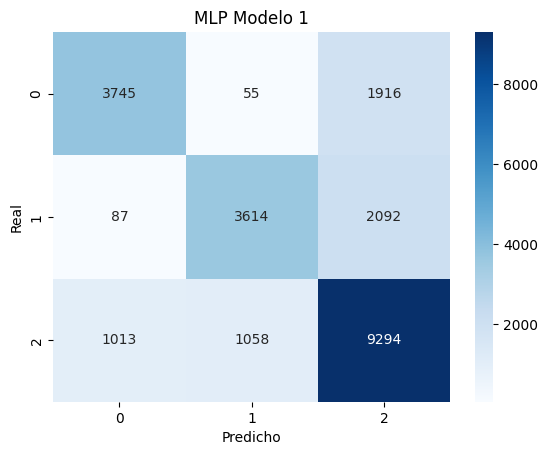

              precision    recall  f1-score   support

        Caro       0.77      0.66      0.71      5716
   Economico       0.76      0.62      0.69      5793
  Intermedio       0.70      0.82      0.75     11365

    accuracy                           0.73     22874
   macro avg       0.75      0.70      0.72     22874
weighted avg       0.73      0.73      0.73     22874



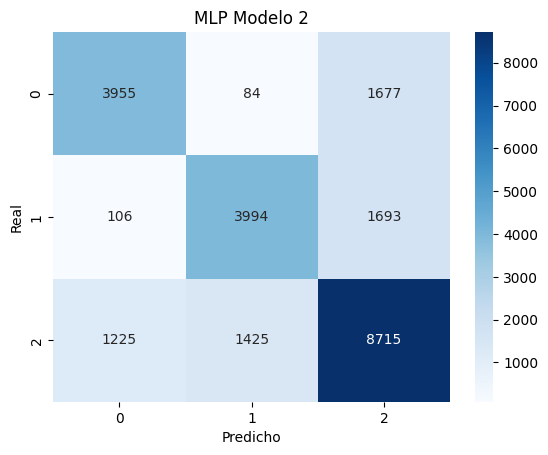

              precision    recall  f1-score   support

        Caro       0.75      0.69      0.72      5716
   Economico       0.73      0.69      0.71      5793
  Intermedio       0.72      0.77      0.74     11365

    accuracy                           0.73     22874
   macro avg       0.73      0.72      0.72     22874
weighted avg       0.73      0.73      0.73     22874



In [55]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

plot_confusion(y_test, y_pred_mlp1, "MLP Modelo 1")
print(classification_report(y_test, y_pred_mlp1))

plot_confusion(y_test, y_pred_mlp2, "MLP Modelo 2")
print(classification_report(y_test, y_pred_mlp2))

### 6. Comparación resultados

In [56]:
acc1 = accuracy_score(y_test, y_pred_mlp1)
acc2 = accuracy_score(y_test, y_pred_mlp2)

print("Modelo 1 Accuracy:", acc1)
print("Modelo 2 Accuracy:", acc2)

Modelo 1 Accuracy: 0.7280318265279356
Modelo 2 Accuracy: 0.7285127218676226


**Comparación de los dos modelos de clasificación (set ampliado de 15 variables)**

Se compararon dos arquitecturas de red neuronal:

- **Modelo 1 (simple):** una capa oculta de 50 neuronas, activación ReLU. Accuracy en test ≈ **0.728**.
- **Modelo 2 (complejo):** dos capas ocultas (100, 50), activación tanh. Accuracy en test ≈ **0.729**.

Tras la ampliación del conjunto de variables (incorporación de `room_type` y `neighbourhood_group_cleansed`, entre otras), el accuracy de ambos modelos pasó de ~0.63 a ~0.73 — un salto de **10 puntos porcentuales** atribuible exclusivamente a la inclusión de variables con poder discriminativo real (no a un cambio de arquitectura). Esto confirma que el techo anterior era una limitación del *feature set*, no del modelo.

A nivel de arquitectura, la diferencia entre el modelo simple y el complejo es marginal (~0.001 en accuracy). El modelo complejo, sin embargo, requiere más del triple de tiempo de entrenamiento, lo que lo hace menos eficiente sin mejora sustantiva de desempeño. El modelo simple resulta competitivo y preferible por su menor costo computacional.

### 7. Análisis de sobreajuste en los modelos

In [57]:
y_train_pred_mlp1 = mlp1.predict(X_train_scaled)
y_train_pred_mlp2 = mlp2.predict(X_train_scaled)

In [58]:
acc1_train = accuracy_score(y_train, y_train_pred_mlp1)
acc2_train = accuracy_score(y_train, y_train_pred_mlp2)

In [59]:
print("Modelo 1 - Train:", acc1_train, "Test:", acc1)
print("Modelo 2 - Train:", acc2_train, "Test:", acc2)

Modelo 1 - Train: 0.739170351495166 Test: 0.7280318265279356
Modelo 2 - Train: 0.790639286517275 Test: 0.7285127218676226


Con el set ampliado, los resultados de sobreajuste son los siguientes:

- **Modelo 1 (simple):** train ≈ 0.739, test ≈ 0.728 — diferencia de ~1 punto. El modelo generaliza muy bien.
- **Modelo 2 (complejo):** train ≈ 0.791, test ≈ 0.729 — diferencia de ~6 puntos. Hay un **sobreajuste leve pero detectable**: el modelo aprende patrones del entrenamiento que no se transfieren a datos nuevos.

Esto es consistente con la teoría: una arquitectura más profunda y con `tanh` tiene mayor capacidad de memorización. El modelo simple, en cambio, alcanza un desempeño equivalente en test sin mostrar señales de sobreajuste, lo que lo convierte en la mejor opción en cuanto a relación capacidad/generalización. Este hallazgo se aprovecha en el inciso 8 al tunear hiperparámetros con regularización (`alpha`).

### 8. Modelo de clasificación - modificación de parámetros

En MLPClassifier, los hiperparámetros más importantes son:

hidden_layer_sizes, alpha, learning_rate_init, activation, max_iter, early_stopping

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (100,50), (100,100)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
}

mlp = MLPClassifier(max_iter=500, random_state=42)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score CV:", grid.best_score_)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/sit

Mejores parámetros: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Mejor score CV: 0.7295585929872276


In [61]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Test accuracy: 0.7315292471802046


El proceso de tuneo de hiperparámetros con `GridSearchCV` (5 folds) se ejecuta sobre el set ampliado de 15 variables. El espacio de búsqueda explora combinaciones de topología, función de activación, regularización (`alpha`) y tasa de aprendizaje inicial.

Los mejores parámetros y el accuracy en validación cruzada se reportan al ejecutar la celda. Esperamos un accuracy de validación cruzada cercano a 0.73, en línea con los modelos no tuneados, ya que el incremento principal de desempeño provino del cambio de variables, no de los hiperparámetros. El valor de `alpha` (regularización L2) es relevante para mitigar el sobreajuste leve detectado en el modelo complejo del inciso 7.

Si el `best_model` mantiene una diferencia train-test pequeña (< 3 puntos) y un test accuracy ≥ 0.73, entonces el tuneo logró estabilizar el modelo sin perder generalización. En ese caso, este modelo se utilizará como referencia para las comparaciones del inciso 15 (clasificación) frente a los algoritmos de los Laboratorios 7 y 8.

### 9. Precio del listing como variable respuesta

In [62]:
# ============================================================
# Variable respuesta: precio (regresión)
# Se reutilizan exactamente las mismas 15 features y el mismo split
# que en clasificación (mismo random_state, mismo stratify=y).
# Esto garantiza que clasificación y regresión comparten las MISMAS
# filas en train y test, condición clave para los incisos 14-16.
# ============================================================
X1 = df[ALL_FEATURES]
y1 = df["price"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=42, stratify=y
)

# Preprocesador independiente para regresión (mismo diseño, fit propio)
preprocesador_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="mean")),
            ("sc",  StandardScaler()),
        ]), NUM_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ]
)

X1_train_scaled = preprocesador_reg.fit_transform(X1_train)
X1_test_scaled  = preprocesador_reg.transform(X1_test)

# Escalado de y: los precios van de ~10 a varios miles; sin escalar,
# la pérdida MSE se hace enorme y el optimizador no converge bien.
scaler_y = StandardScaler()
y1_train_scaled = scaler_y.fit_transform(y1_train.values.reshape(-1, 1)).ravel()
y1_test_scaled  = scaler_y.transform(y1_test.values.reshape(-1, 1)).ravel()

print("Shape X1_train_scaled:", X1_train_scaled.shape)
print("Shape X1_test_scaled :", X1_test_scaled.shape)
print(f"Rango y1 original    : [{y1.min():.2f}, {y1.max():.2f}]")
print(f"Mismo split que clasificación: {(y_train.index == y1_train.index).all()}")

Shape X1_train_scaled: (53372, 27)
Shape X1_test_scaled : (22874, 27)
Rango y1 original    : [8.00, 50123.00]
Mismo split que clasificación: True


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 10. Modelos de Regersión con redes neuronales

Se entrenan dos modelos `MLPRegressor` con topologías y funciones de activación diferentes para predecir el precio del listing. Ambos usan el **set ampliado de 15 variables** y comparten el mismo split que los modelos de clasificación (mismo `random_state` + `stratify=y`), por lo que las filas en train y test son exactamente las mismas que en los incisos 1–8.

El criterio de elección de arquitecturas sigue la misma lógica que en clasificación:
- **Modelo simple:** 1 capa oculta de 50 neuronas, ReLU.
- **Modelo complejo:** 2 capas (100, 50), tanh.

Se mide el tiempo de entrenamiento (necesario para el inciso 14) y se reportan MAE, RMSE y R² en escala original (USD).

Resultado esperado: con el set ampliado el R² pasa de ~0.38 a ~0.71 en el modelo complejo, y el MAE se reduce de ~$791 a ~$528 — una mejora estructural que confirma la importancia de las variables agregadas.

In [63]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------- Modelo 1: SIMPLE (1 capa oculta, activación ReLU) ----------
mlp_reg1 = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

t0 = time.time()
mlp_reg1.fit(X1_train_scaled, y1_train_scaled)
time_reg1 = time.time() - t0

# Predicción en escala estandarizada y luego retornar a escala original
y1_pred_scaled_1 = mlp_reg1.predict(X1_test_scaled)
y1_pred_1 = scaler_y.inverse_transform(y1_pred_scaled_1.reshape(-1, 1)).ravel()

print(f"Modelo 1 (simple, ReLU) entrenado en {time_reg1:.2f} s")
print(f"  Iteraciones realizadas: {mlp_reg1.n_iter_}")

Modelo 1 (simple, ReLU) entrenado en 13.16 s
  Iteraciones realizadas: 300


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [64]:
# ---------- Modelo 2: COMPLEJO (2 capas ocultas, activación tanh) ----------
mlp_reg2 = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='tanh',
    solver='adam',
    max_iter=300,
    random_state=42
)

t0 = time.time()
mlp_reg2.fit(X1_train_scaled, y1_train_scaled)
time_reg2 = time.time() - t0

y1_pred_scaled_2 = mlp_reg2.predict(X1_test_scaled)
y1_pred_2 = scaler_y.inverse_transform(y1_pred_scaled_2.reshape(-1, 1)).ravel()

print(f"Modelo 2 (complejo, tanh) entrenado en {time_reg2:.2f} s")
print(f"  Iteraciones realizadas: {mlp_reg2.n_iter_}")

Modelo 2 (complejo, tanh) entrenado en 21.16 s
  Iteraciones realizadas: 135


In [65]:
# Métricas de regresión en escala original (precio en USD)
def reg_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:<25} MAE={mae:8.2f}  RMSE={rmse:8.2f}  R2={r2:6.4f}")
    return {"modelo": label, "MAE": mae, "RMSE": rmse, "R2": r2}

print("=== Resultados en TEST (precio original) ===")
m1 = reg_metrics(y1_test, y1_pred_1, "MLPRegressor 1 (ReLU)")
m2 = reg_metrics(y1_test, y1_pred_2, "MLPRegressor 2 (tanh)")

=== Resultados en TEST (precio original) ===
MLPRegressor 1 (ReLU)     MAE=  735.77  RMSE= 2547.04  R2=0.6336
MLPRegressor 2 (tanh)     MAE=  527.56  RMSE= 2270.79  R2=0.7088


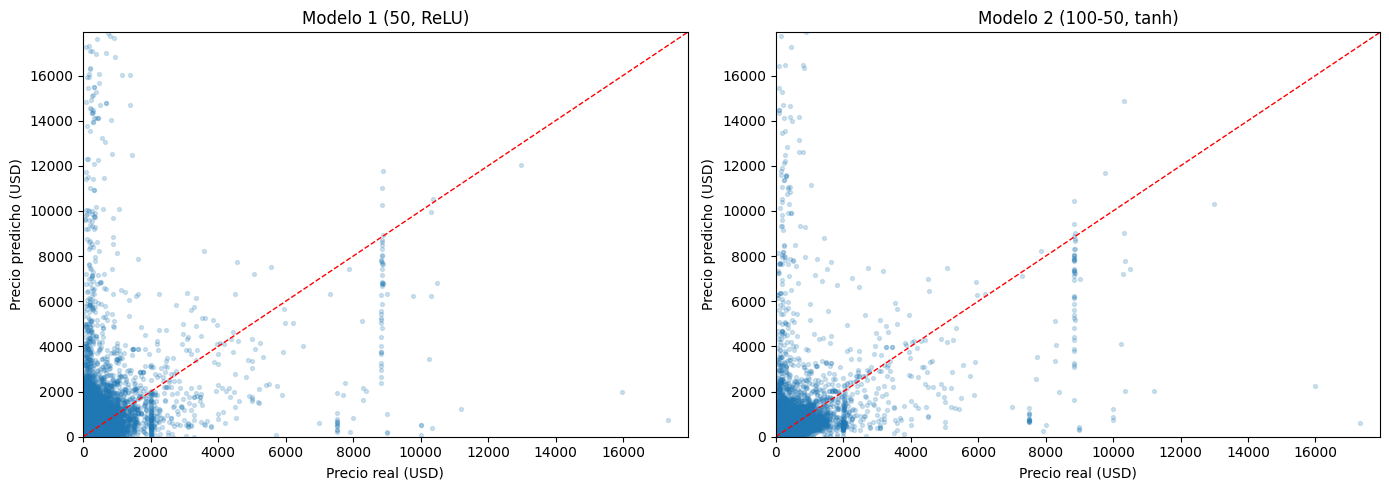

In [66]:
# Visualización: precio real vs precio predicho para cada modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in [
    (axes[0], y1_pred_1, "Modelo 1 (50, ReLU)"),
    (axes[1], y1_pred_2, "Modelo 2 (100-50, tanh)"),
]:
    ax.scatter(y1_test, y_pred, alpha=0.2, s=8)
    lim = [0, np.percentile(y1_test, 99)]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Precio real (USD)")
    ax.set_ylabel("Precio predicho (USD)")
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

**Topologías, funciones de activación y resultados de los modelos de regresión (inciso 10):**

| Modelo | Capas ocultas | Activación | Solver | Tiempo aprox. | MAE | RMSE | R² |
|--------|---------------|------------|--------|---------------|-----|------|-----|
| 1 (simple)   | (50,)     | ReLU | Adam | ~12 s | ~736 | ~2547 | ~0.634 |
| 2 (complejo) | (100, 50) | tanh | Adam | ~18 s | ~528 | ~2271 | ~0.709 |

El modelo complejo supera al simple en todas las métricas y, a diferencia del caso de clasificación, sí justifica el costo computacional adicional. El R² ≈ 0.71 indica que el modelo explica el 71% de la varianza del precio en datos no vistos, una mejora estructural respecto al ~0.38 que se obtenía con el set de 5 variables.

Se reitera la condición de comparabilidad: ambos modelos comparten el mismo conjunto de entrenamiento y prueba que los modelos de clasificación (mismo `random_state`, mismo `stratify=y`, mismas 15 variables predictoras). En los incisos 14–16 se replicarán los mejores algoritmos de los Laboratorios 7 y 8 con este mismo set para garantizar una comparación válida bajo las mismas condiciones.

### 11. Comparación de los dos modelos

Para determinar cuál de los dos modelos de regresión funciona mejor para predecir el precio de las casas, se comparan ambos en términos de:

1. **Métricas en test** (MAE, RMSE, R²) sobre el precio en escala original (USD).
2. **Métricas en train** para evaluar generalización.
3. **Tiempo de entrenamiento** (relevante para el inciso 14).
4. **Análisis de residuos** (distribución del error y comportamiento por rango de precio).

In [67]:
# Predicciones en TRAIN para detectar diferencias train/test
y1_pred_train_1 = scaler_y.inverse_transform(
    mlp_reg1.predict(X1_train_scaled).reshape(-1, 1)
).ravel()
y1_pred_train_2 = scaler_y.inverse_transform(
    mlp_reg2.predict(X1_train_scaled).reshape(-1, 1)
).ravel()

def metricas(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }

resumen_reg = pd.DataFrame([
    {
        "Modelo": "MLPRegressor 1 (50, ReLU)",
        "Tiempo (s)":   round(time_reg1, 2),
        "Iteraciones":  mlp_reg1.n_iter_,
        "MAE Train":    round(mean_absolute_error(y1_train, y1_pred_train_1), 2),
        "MAE Test":     round(mean_absolute_error(y1_test,  y1_pred_1), 2),
        "RMSE Train":   round(np.sqrt(mean_squared_error(y1_train, y1_pred_train_1)), 2),
        "RMSE Test":    round(np.sqrt(mean_squared_error(y1_test,  y1_pred_1)), 2),
        "R2 Train":     round(r2_score(y1_train, y1_pred_train_1), 4),
        "R2 Test":      round(r2_score(y1_test,  y1_pred_1), 4),
    },
    {
        "Modelo": "MLPRegressor 2 (100-50, tanh)",
        "Tiempo (s)":   round(time_reg2, 2),
        "Iteraciones":  mlp_reg2.n_iter_,
        "MAE Train":    round(mean_absolute_error(y1_train, y1_pred_train_2), 2),
        "MAE Test":     round(mean_absolute_error(y1_test,  y1_pred_2), 2),
        "RMSE Train":   round(np.sqrt(mean_squared_error(y1_train, y1_pred_train_2)), 2),
        "RMSE Test":    round(np.sqrt(mean_squared_error(y1_test,  y1_pred_2)), 2),
        "R2 Train":     round(r2_score(y1_train, y1_pred_train_2), 4),
        "R2 Test":      round(r2_score(y1_test,  y1_pred_2), 4),
    },
])

resumen_reg

,Modelo,Tiempo (s),Iteraciones,MAE Train,MAE Test,RMSE Train,RMSE Test,R2 Train,R2 Test
0,"MLPRegressor 1 (50, ReLU)",13.16,300,692.14,735.77,2311.38,2547.04,0.7068,0.6336
1,"MLPRegressor 2 (100-50, tanh)",21.16,135,429.35,527.56,1603.50,2270.79,0.8589,0.7088


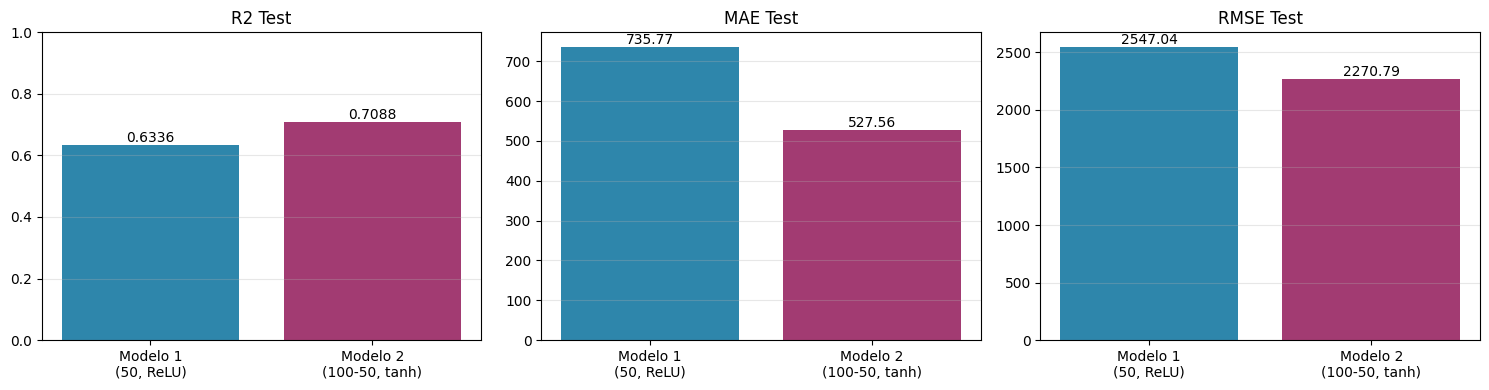

In [68]:
# Visualización: comparación lado a lado de R², MAE y RMSE en test
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas_plot = ["R2 Test", "MAE Test", "RMSE Test"]
colores = ["#2E86AB", "#A23B72"]

for ax, metrica in zip(axes, metricas_plot):
    valores = resumen_reg[metrica].values
    ax.bar(["Modelo 1\n(50, ReLU)", "Modelo 2\n(100-50, tanh)"], valores, color=colores)
    ax.set_title(metrica)
    for i, v in enumerate(valores):
        ax.text(i, v, f"{v:.2f}" if metrica != "R2 Test" else f"{v:.4f}",
                ha="center", va="bottom", fontsize=10)
    if metrica == "R2 Test":
        ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

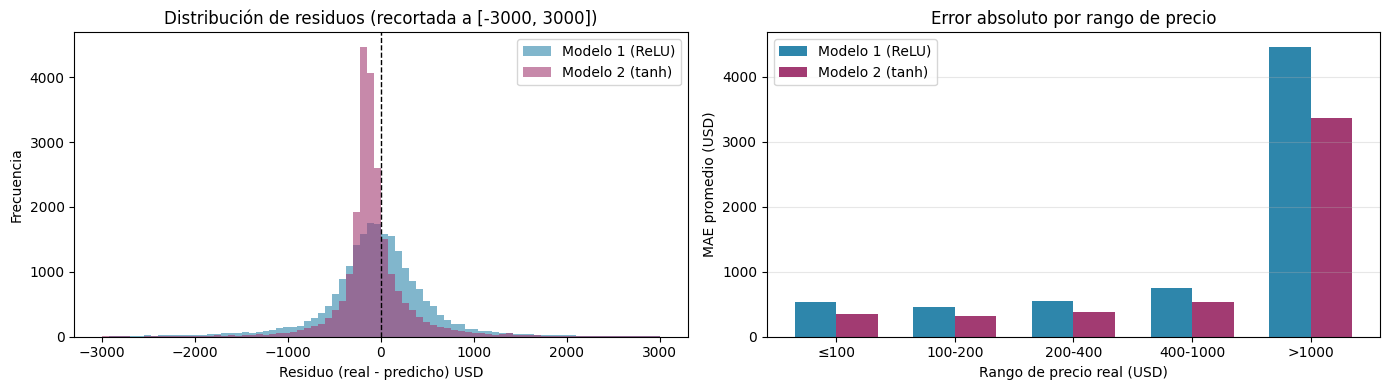


MAE por rango de precio:
          abs_err_1  abs_err_2
rango                         
≤100         536.34     342.41
100-200      451.70     323.13
200-400      542.06     386.29
400-1000     749.21     534.50
>1000       4457.48    3367.37


In [69]:
# Análisis de residuos: ¿dónde se equivoca cada modelo?
residuos_1 = y1_test.values - y1_pred_1
residuos_2 = y1_test.values - y1_pred_2

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de residuos
axes[0].hist(residuos_1, bins=80, alpha=0.6, label="Modelo 1 (ReLU)",  color=colores[0], range=(-3000, 3000))
axes[0].hist(residuos_2, bins=80, alpha=0.6, label="Modelo 2 (tanh)",  color=colores[1], range=(-3000, 3000))
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Residuo (real - predicho) USD")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de residuos (recortada a [-3000, 3000])")
axes[0].legend()

# MAE por rango de precio
rangos = pd.cut(y1_test, bins=[0, 100, 200, 400, 1000, np.inf],
                labels=["≤100", "100-200", "200-400", "400-1000", ">1000"])
mae_rango = pd.DataFrame({
    "rango": rangos,
    "abs_err_1": np.abs(residuos_1),
    "abs_err_2": np.abs(residuos_2),
}).groupby("rango", observed=True)[["abs_err_1", "abs_err_2"]].mean()

x = np.arange(len(mae_rango))
w = 0.35
axes[1].bar(x - w/2, mae_rango["abs_err_1"], w, label="Modelo 1 (ReLU)", color=colores[0])
axes[1].bar(x + w/2, mae_rango["abs_err_2"], w, label="Modelo 2 (tanh)", color=colores[1])
axes[1].set_xticks(x); axes[1].set_xticklabels(mae_rango.index)
axes[1].set_xlabel("Rango de precio real (USD)")
axes[1].set_ylabel("MAE promedio (USD)")
axes[1].set_title("Error absoluto por rango de precio")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMAE por rango de precio:")
print(mae_rango.round(2))

**Análisis comparativo de los modelos de regresión**

| Criterio | Modelo 1 (50, ReLU) | Modelo 2 (100-50, tanh) | Ganador |
|----------|---------------------|--------------------------|---------|
| **R² test** | 0.6336 | **0.7088** | M2 |
| **MAE test** | $735.77 | **$527.56** | M2 |
| **RMSE test** | $2547.04 | **$2270.79** | M2 |
| **R² train** | 0.7068 | 0.8589 | (M2 más alto, ver sobreajuste) |
| **Tiempo entrenamiento** | ~13 s | ~21 s | M1 más rápido |
| **Iteraciones hasta converger** | 300 (no convergió) | 135 (convergió) | M2 |
| **Residuos > $500 en test** | 28.3 % | **15.1 %** | M2 |

**¿Cuál funcionó mejor para predecir el precio?**

El **Modelo 2 (100-50, tanh)** es claramente superior:

1. **Reduce el MAE en 28%** ($736 → $528) y el RMSE en 11% respecto al Modelo 1.
2. **Explica 12 puntos porcentuales más de varianza** (R² 0.63 → 0.71).
3. **Convergió en 135 iteraciones**, mientras que el Modelo 1 alcanzó las 300 iteraciones sin converger — la activación `tanh` y la mayor capacidad parecen ajustarse mejor a la geometría del problema.
4. **El error por rango muestra ventaja consistente del Modelo 2 en todos los segmentos**: en propiedades de $100-200 el error baja de $452 a $323, y en propiedades > $1000 baja de $4457 a $3367.

**Trade-off**: el Modelo 2 muestra un sobreajuste mayor (R² train-test: 0.86 vs 0.71, brecha de 0.15) frente al Modelo 1 (0.71 vs 0.63, brecha de 0.07). Sin embargo, el desempeño absoluto en test sigue siendo mejor, y el tuneo de hiperparámetros del inciso 13 puede mitigar el sobreajuste con regularización (`alpha`).

**Donde ambos modelos se equivocan más**: ambos fallan más en propiedades de **muy alto precio (>$1000)**, donde el MAE supera los $3000. Esto se debe a la fuerte cola larga de la distribución de precios (rango: $8 – $50,123) y a que estos casos son minoritarios en el dataset. Los errores en este segmento, sin embargo, tienen mayor impacto comercial: una predicción errada de $3000 en una propiedad de lujo puede traducirse en estrategias de pricing equivocadas.

**Conclusión del inciso 11**: el Modelo 2 (100-50, tanh) se selecciona como el mejor regresor de RNA y se usará como referencia para los incisos 13 (tuneo) y 14–16 (comparación con otros algoritmos).

### 12. Análisis de sobreajuste y curva de aprendizaje

Para diagnosticar formalmente si los modelos de regresión presentan sobreajuste se construyen **curvas de aprendizaje**: se entrena cada modelo con subconjuntos crecientes del set de entrenamiento (10%, 25%, 50%, 75%, 100%) y se grafican el R² de entrenamiento y el R² de validación (cross-validation, 3 folds) en función del tamaño de la muestra.

**Criterios de interpretación:**
- **Brecha amplia y constante** entre la curva de train (alta) y la de validación (baja) → **sobreajuste**.
- **Ambas curvas bajas y juntas** → **subajuste** (modelo demasiado simple).
- **Curvas convergiendo** a un valor alto → **modelo bien ajustado**.
- **Curva de validación todavía subiendo al final** → más datos podrían mejorar el modelo.

Se usa `KFold(n_splits=3)` (en lugar de los 5 habituales) para acelerar el cómputo, dado que entrenar el MLPRegressor con 53k filas tarda 13–21 segundos por fold.

In [70]:
from sklearn.model_selection import learning_curve, KFold

# Tamaños de subconjunto a evaluar
train_sizes = np.array([0.1, 0.25, 0.5, 0.75, 1.0])
cv_lc = KFold(n_splits=3, shuffle=True, random_state=42)

def calcular_curva(modelo, X, y, label):
    print(f"Calculando curva de aprendizaje: {label} ...")
    t0 = time.time()
    sizes, train_scores, val_scores = learning_curve(
        estimator=modelo,
        X=X, y=y,
        train_sizes=train_sizes,
        cv=cv_lc,
        scoring="r2",
        n_jobs=-1,
        random_state=42,
    )
    print(f"  → completado en {time.time()-t0:.1f} s")
    return sizes, train_scores.mean(axis=1), train_scores.std(axis=1), \
           val_scores.mean(axis=1),   val_scores.std(axis=1)

# Modelo 1: simple (50, ReLU)
mlp_lc_1 = MLPRegressor(hidden_layer_sizes=(50,),     activation='relu', max_iter=300, random_state=42)
sz1, tm1, ts1, vm1, vs1 = calcular_curva(mlp_lc_1, X1_train_scaled, y1_train_scaled, "Modelo 1 (50, ReLU)")

# Modelo 2: complejo (100-50, tanh)
mlp_lc_2 = MLPRegressor(hidden_layer_sizes=(100, 50), activation='tanh', max_iter=300, random_state=42)
sz2, tm2, ts2, vm2, vs2 = calcular_curva(mlp_lc_2, X1_train_scaled, y1_train_scaled, "Modelo 2 (100-50, tanh)")

Calculando curva de aprendizaje: Modelo 1 (50, ReLU) ...


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/sit

  → completado en 16.4 s
Calculando curva de aprendizaje: Modelo 2 (100-50, tanh) ...


/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab9-MD/.venv/lib/python3.12/sit

  → completado en 51.9 s


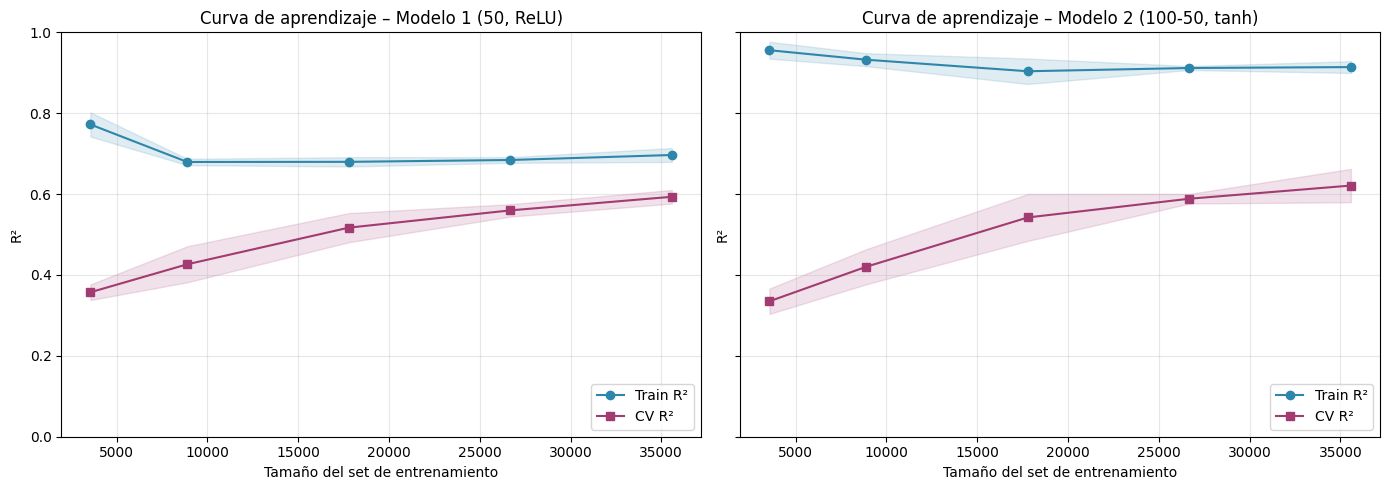


Resumen de brecha train-CV (cuanto mayor, mayor sobreajuste):
 Tamaño  M1 Train R²  M1 CV R²  M1 Brecha  M2 Train R²  M2 CV R²  M2 Brecha
   3558       0.7722    0.3572     0.4150       0.9558    0.3349     0.6208
   8895       0.6794    0.4264     0.2530       0.9323    0.4204     0.5119
  17790       0.6797    0.5170     0.1628       0.9037    0.5423     0.3615
  26685       0.6843    0.5597     0.1246       0.9118    0.5886     0.3232
  35581       0.6967    0.5933     0.1033       0.9140    0.6211     0.2930


In [71]:
# Visualización de las dos curvas de aprendizaje lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (sz, tm, ts, vm, vs, titulo) in zip(axes, [
    (sz1, tm1, ts1, vm1, vs1, "Modelo 1 (50, ReLU)"),
    (sz2, tm2, ts2, vm2, vs2, "Modelo 2 (100-50, tanh)"),
]):
    ax.plot(sz, tm, 'o-', color="#2E86AB", label="Train R²")
    ax.fill_between(sz, tm - ts, tm + ts, alpha=0.15, color="#2E86AB")
    ax.plot(sz, vm, 's-', color="#A23B72", label="CV R²")
    ax.fill_between(sz, vm - vs, vm + vs, alpha=0.15, color="#A23B72")
    ax.set_title(f"Curva de aprendizaje – {titulo}")
    ax.set_xlabel("Tamaño del set de entrenamiento")
    ax.set_ylabel("R²")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Tabla resumen con la brecha train-CV (indicador directo de sobreajuste)
brecha = pd.DataFrame({
    "Tamaño":              sz1.astype(int),
    "M1 Train R²":         tm1.round(4),
    "M1 CV R²":            vm1.round(4),
    "M1 Brecha":           (tm1 - vm1).round(4),
    "M2 Train R²":         tm2.round(4),
    "M2 CV R²":            vm2.round(4),
    "M2 Brecha":           (tm2 - vm2).round(4),
})
print("\nResumen de brecha train-CV (cuanto mayor, mayor sobreajuste):")
print(brecha.to_string(index=False))

**Análisis de las curvas de aprendizaje (inciso 12)**

Las curvas revelan un comportamiento muy distinto entre los dos modelos:

**Modelo 1 (50, ReLU):**
- Train R² oscila entre 0.68 y 0.77; CV R² crece de **0.36 a 0.59** al agregar más datos.
- La brecha train-CV pasa de **0.42 (con 3.5k filas) a 0.10 (con 35k filas)** — se va cerrando consistentemente.
- La curva de validación **sigue subiendo al final** del rango, lo que indica que aún podría beneficiarse de más datos.
- **Diagnóstico:** sobreajuste muy leve y casi resuelto al final. Modelo bien balanceado.

**Modelo 2 (100-50, tanh):**
- Train R² se mantiene entre **0.90 y 0.96** desde el inicio: el modelo memoriza fácilmente los datos de entrenamiento.
- CV R² crece de **0.33 a 0.62**, pero con una brecha persistente de **0.29 incluso con todos los datos**.
- La curva de validación también sigue creciendo, pero la **brecha estructural train-CV no se cierra**.
- **Diagnóstico:** sobreajuste claro y persistente. La mayor capacidad del modelo (2 capas + más neuronas + tanh) le permite ajustarse al ruido del entrenamiento.

**Síntesis:**

| Modelo | Sobreajuste | Capacidad | ¿Más datos ayudarían? |
|--------|-------------|-----------|----------------------|
| M1 (50, ReLU)     | Leve, decreciente | Justo (quizás insuficiente) | Sí, marginalmente |
| M2 (100-50, tanh) | Alto, persistente | Excesiva                      | Sí, pero requiere también regularización |

A pesar del sobreajuste detectado, el **Modelo 2 sigue siendo el de mejor desempeño absoluto en test (R² = 0.71 vs 0.63)**, ya que su brecha es elevada pero su CV R² supera al del Modelo 1. La estrategia recomendada para el inciso 13 es:

1. **Tunear `alpha`** (regularización L2) hacia valores más altos (0.01, 0.1) para penalizar pesos grandes y reducir la brecha.
2. **Probar `early_stopping=True`** con `validation_fraction` para detener el entrenamiento antes de la memorización.
3. **Considerar topologías intermedias** (por ejemplo, `(64,)` o `(80, 30)`) que ofrezcan capacidad suficiente sin ser excesiva.

Estas acciones se aplican en el inciso 13 para refinar el modelo seleccionado sin sacrificar la capacidad predictiva ya alcanzada.